In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle, json


In [3]:
df = pd.read_csv(r"C:\Users\Rajesh Kinjarapu\Desktop\Smart Health Assistant\Datasets\diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [9]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [11]:
# Replace Impossible Zeros With NaN
cols_with_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

df.isnull().sum()


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [15]:
# Handling Missing Values
for col in cols_with_zero:
    df[col] = df[col].fillna(df[col].median())


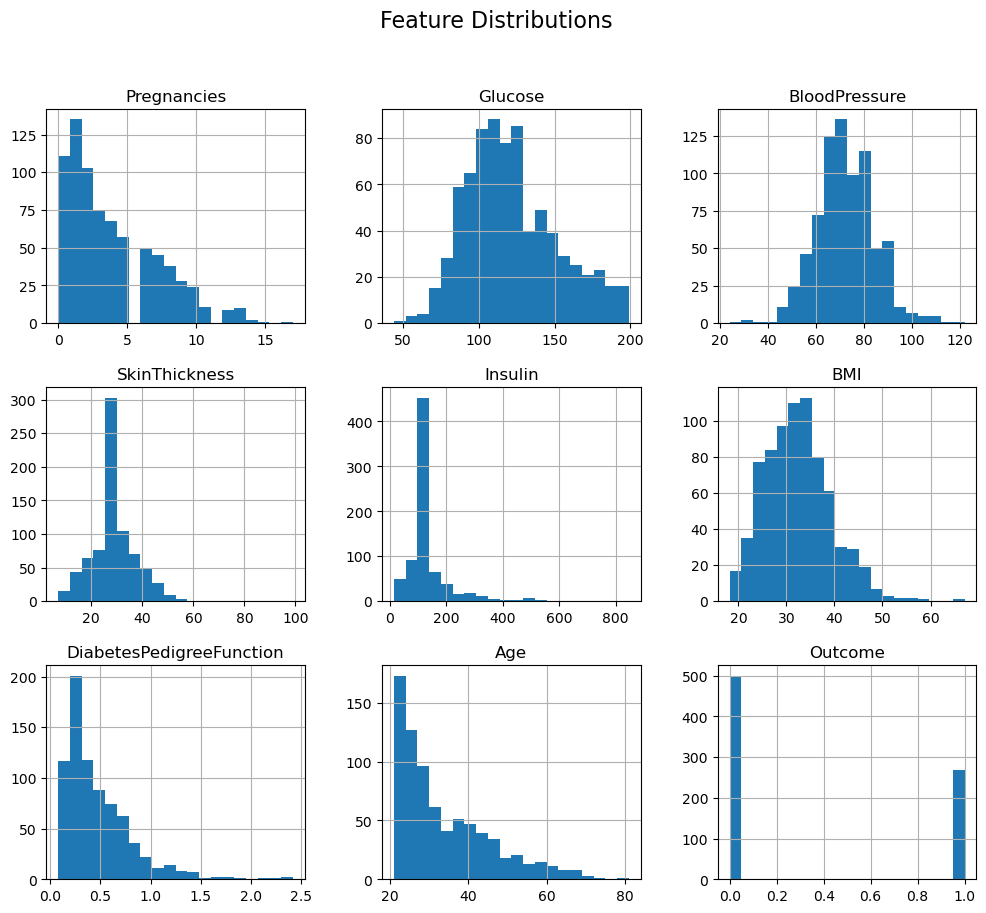

In [17]:
# 6.1 Distribution Plots
df.hist(figsize=(12,10), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


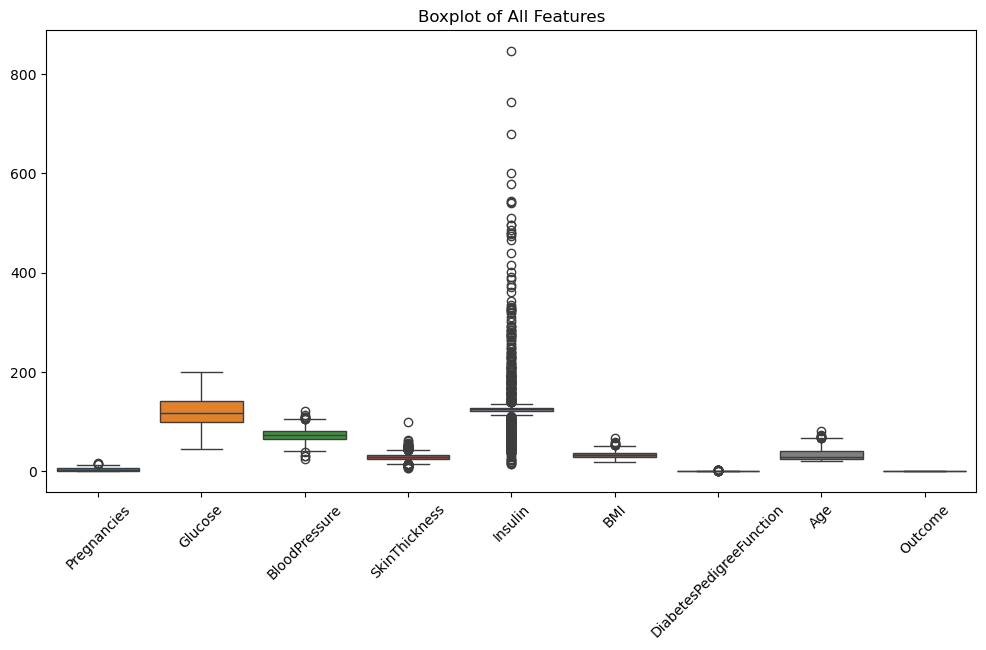

In [19]:
# 6.2 Boxplots (Outlier Detection)
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("Boxplot of All Features")
plt.xticks(rotation=45)
plt.show()


In [21]:
# Outlier Treatment using IQR
def remove_outliers(col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

for col in df.columns:
    if col != "Outcome":
        remove_outliers(col)


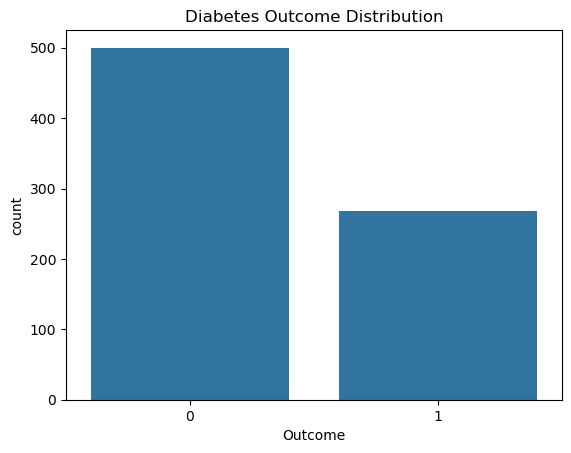

In [23]:
# 8.1 Diabetes Outcome Count
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Outcome Distribution")
plt.show()


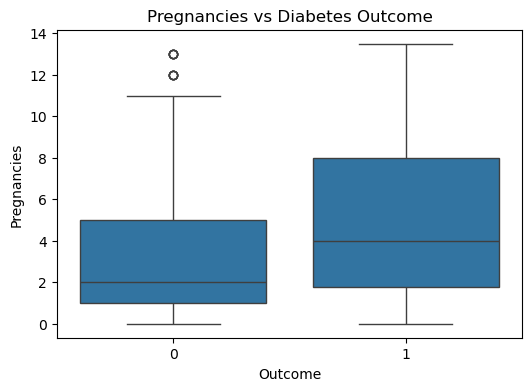

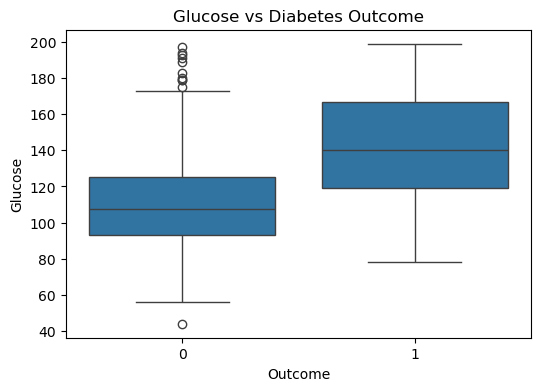

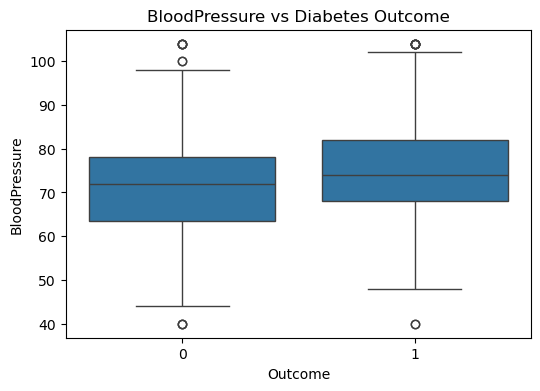

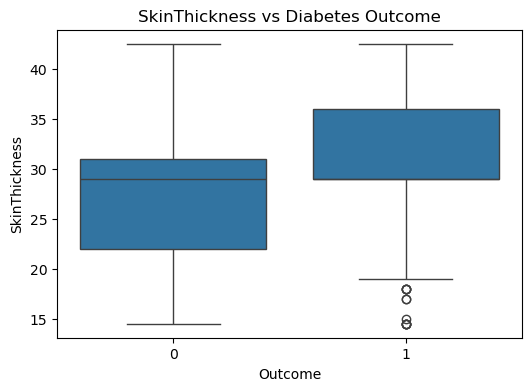

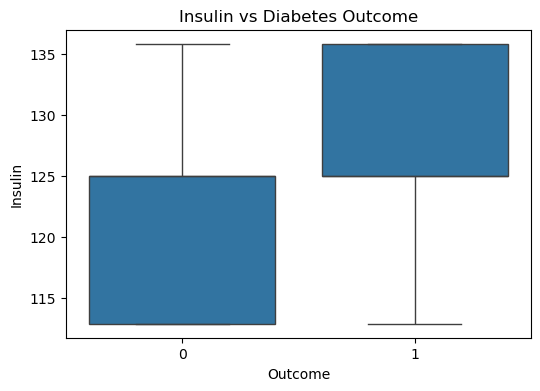

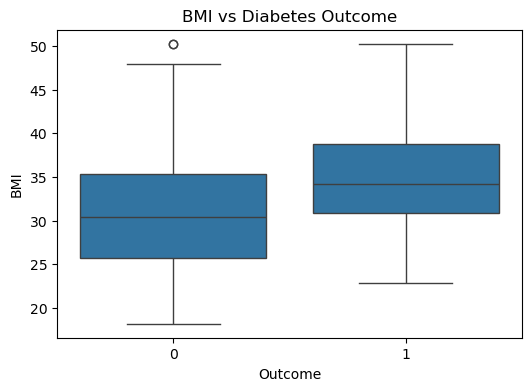

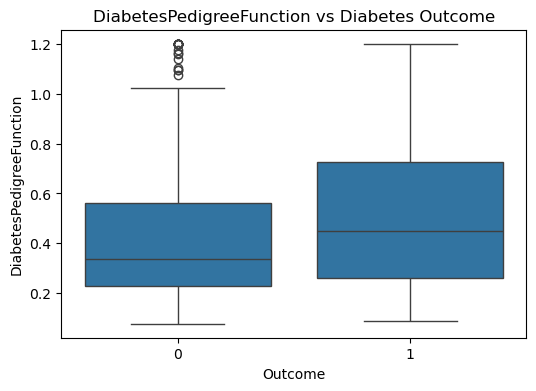

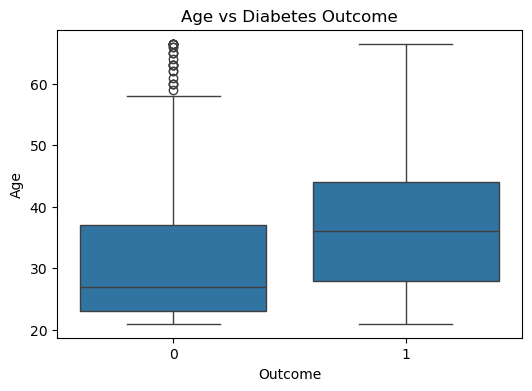

In [27]:
# 8.2 Compare features against Outcome
for col in df.columns:
    if col != "Outcome":
        plt.figure(figsize=(6,4))
        sns.boxplot(x='Outcome', y=col, data=df)
        plt.title(f"{col} vs Diabetes Outcome")
        plt.show()


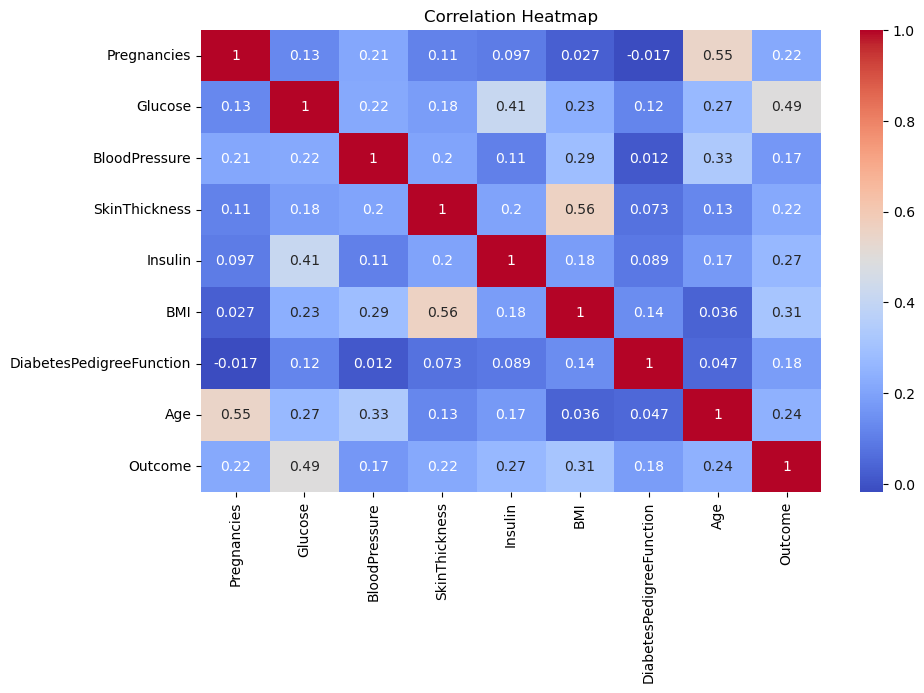

In [31]:
# Multivariate Analysis
# 9.1 Correlation Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


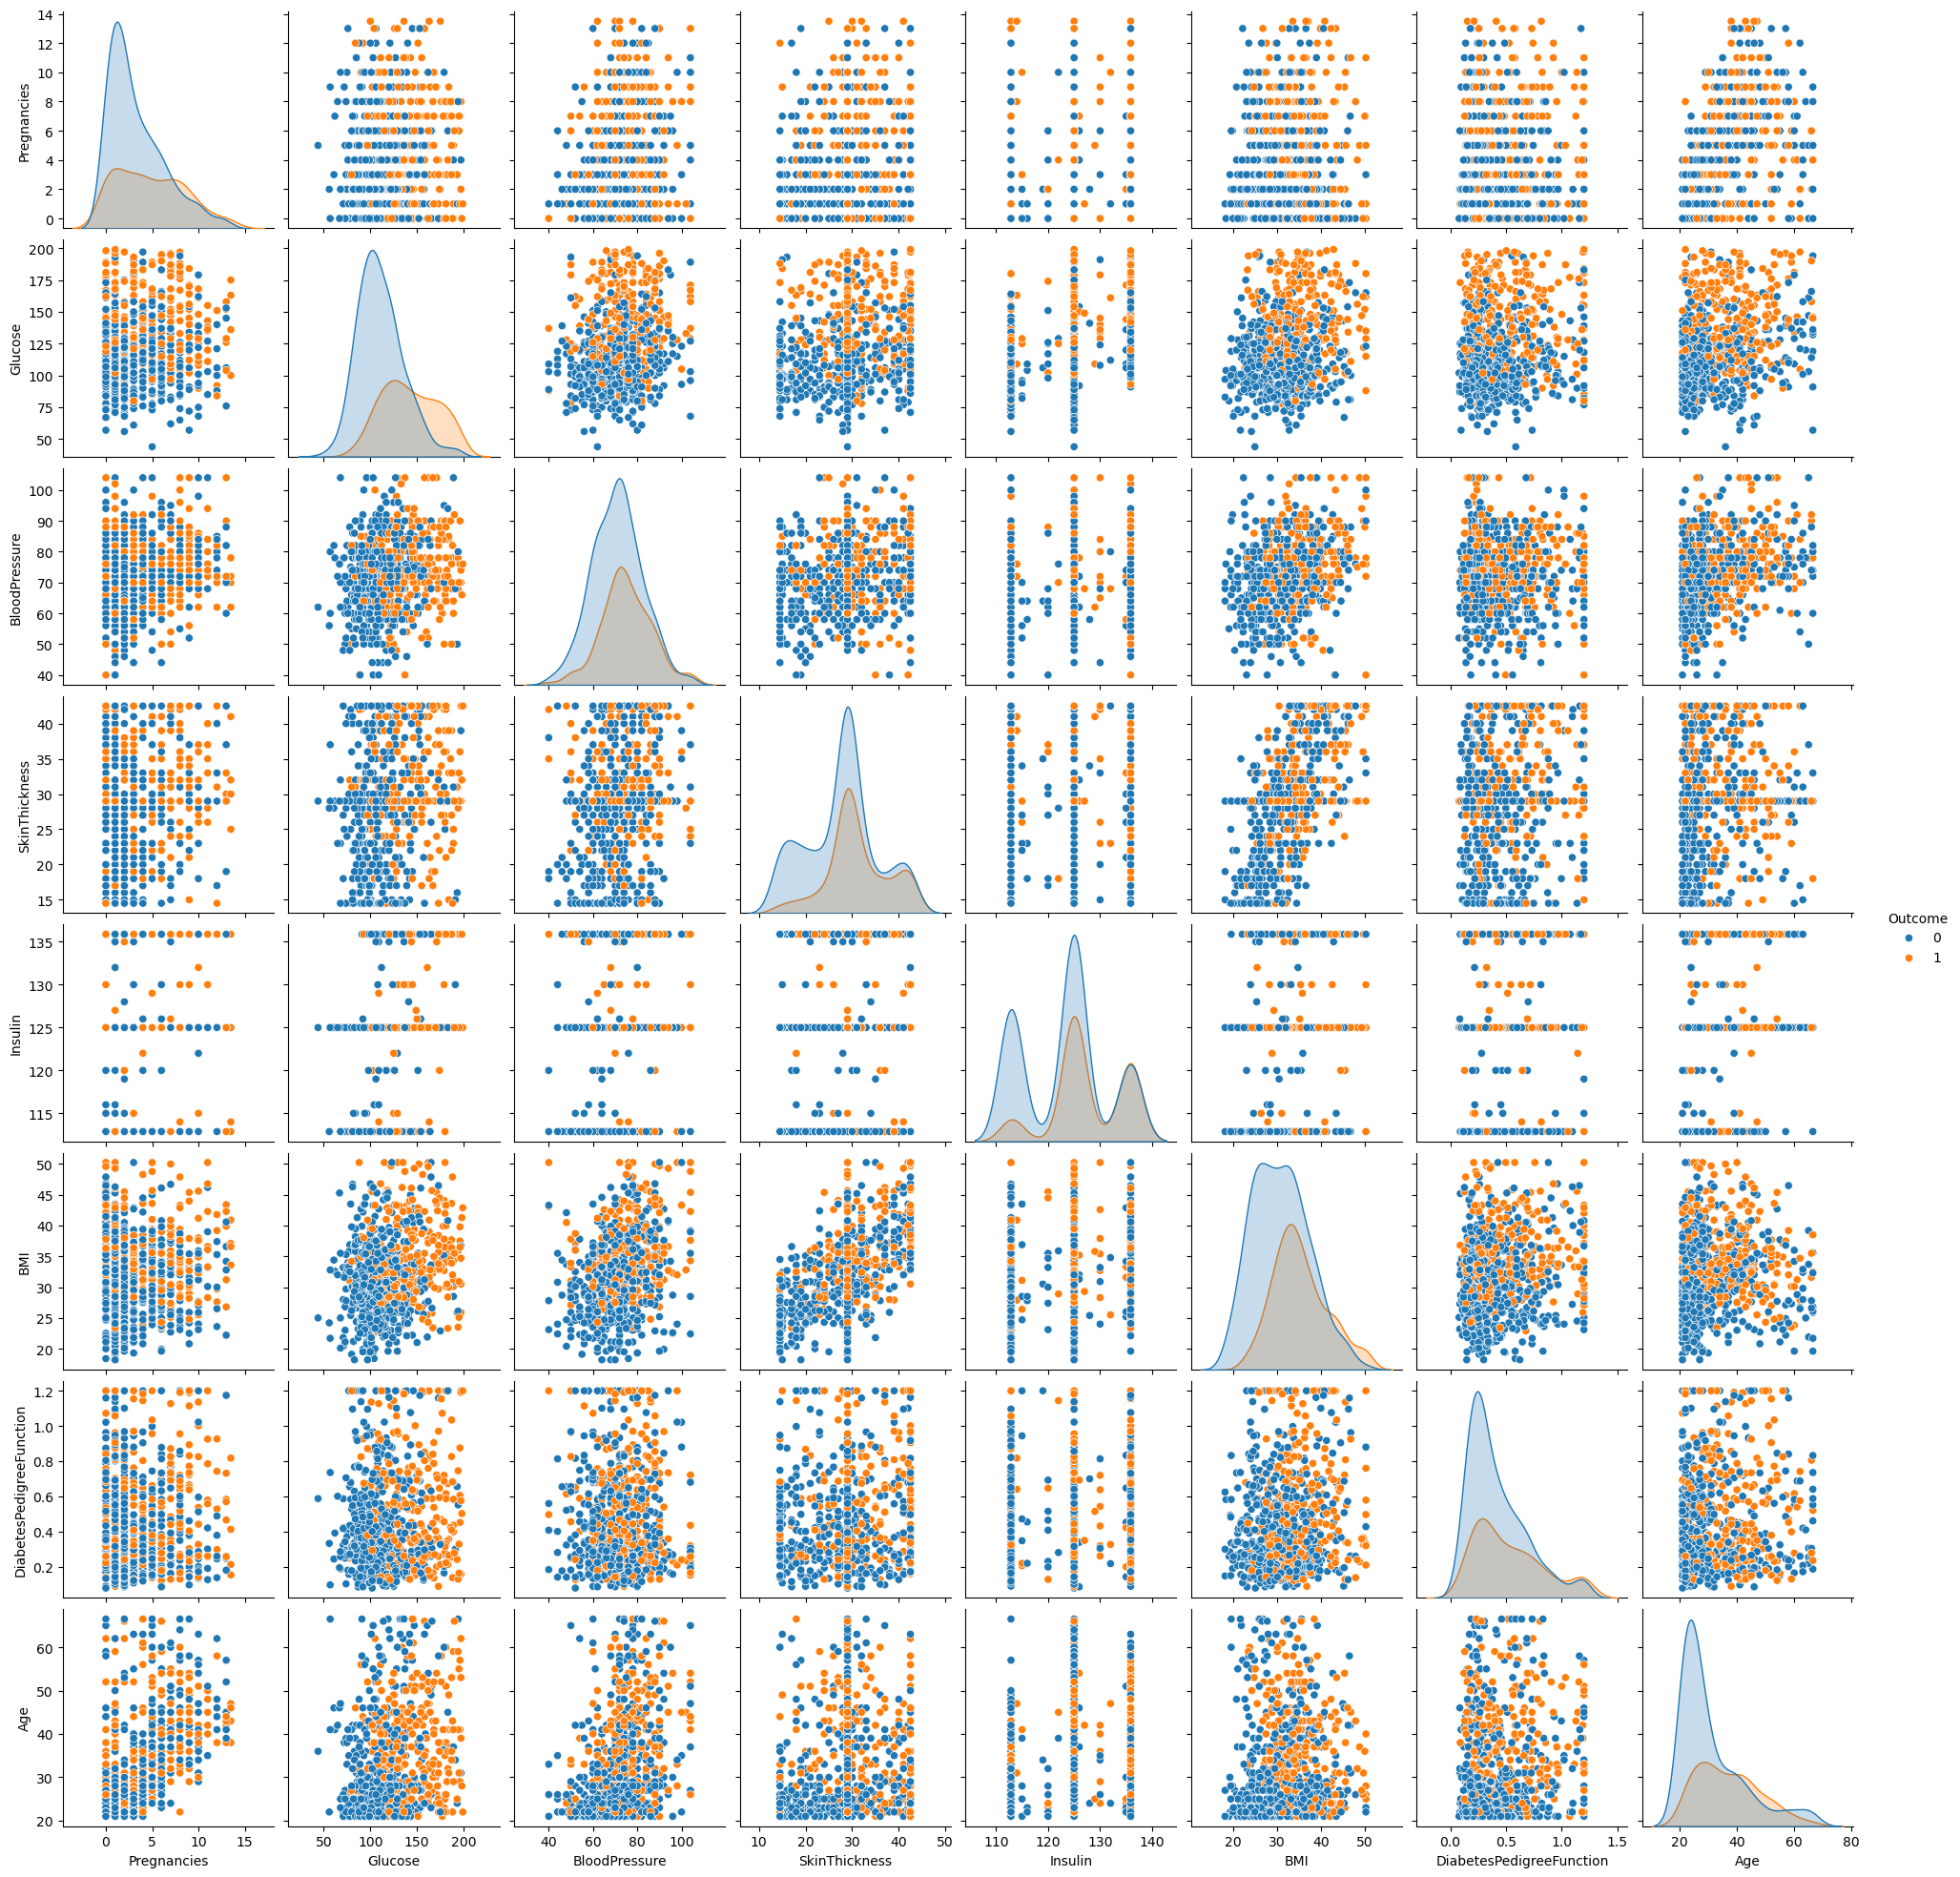

In [33]:
# 9.2 Pairplot
sns.pairplot(df, hue='Outcome', diag_kind='kde')
plt.show()


In [35]:
# Feature Engineering
# 10.1 Create Age Groups (if age exists)

if 'Age' in df.columns:
    df['Age_Group'] = pd.cut(
        df['Age'],
        bins=[20,30,40,50,60,100],
        labels=['20-30','30-40','40-50','50-60','60+']
    )


In [37]:
# 10.2 Create BMI Category
def bmi_cat(bmi):
    if bmi < 18.5: return "Underweight"
    elif bmi < 25: return "Normal"
    elif bmi < 30: return "Overweight"
    else: return "Obese"

df['BMI_Category'] = df['BMI'].apply(bmi_cat)


In [39]:
# 10.3 Feature Interaction
df['Glucose_BMI'] = df['Glucose'] * df['BMI']
df['Insulin_Glucose'] = df['Insulin'] / (df['Glucose'] + 1)


In [41]:
# Scaling Features

from sklearn.preprocessing import StandardScaler

num_cols = df.select_dtypes(include=['float64','int64']).columns
num_cols = num_cols.drop("Outcome")

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])


In [43]:
# Final Cleaned Dataset Preview

df_scaled.head()
df_scaled.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_BMI,Insulin_Glucose
count,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,7.680000e+02,768.000000,7.680000e+02,7.680000e+02
mean,-6.938894e-17,4.625929e-18,-3.827956e-16,1.734723e-16,-5.944319e-16,-4.417762e-16,-2.081668e-16,2.220446e-16,0.348958,-1.827242e-16,-3.538836e-16
std,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,1.000652e+00,0.476951,1.000652e+00,1.000652e+00
min,-1.148194e+00,-2.552931e+00,-2.768136e+00,-1.931634e+00,-1.494110e+00,-2.130134e+00,-1.334619e+00,-1.049828e+00,0.000000,-1.996864e+00,-1.789224e+00
25%,-8.489700e-01,-7.201630e-01,-7.150082e-01,-5.198700e-01,-4.035031e-01,-7.343936e-01,-7.538762e-01,-7.916706e-01,0.000000,-7.357044e-01,-6.965415e-01
50%,-2.505221e-01,-1.530732e-01,-3.063207e-02,1.794466e-02,3.906197e-02,-1.401134e-02,-3.027713e-01,-3.614087e-01,0.000000,-1.645841e-01,-4.799097e-02
75%,6.471497e-01,6.112653e-01,6.537440e-01,4.213057e-01,3.235681e-01,6.313311e-01,5.862995e-01,6.712197e-01,1.000000,5.476829e-01,5.566778e-01
max,2.891329e+00,2.542658e+00,2.706872e+00,1.833069e+00,1.414175e+00,2.679918e+00,2.596563e+00,2.865555e+00,1.000000,3.496207e+00,6.776324e+00


In [68]:
# Drop categorical columns
df_model = df_scaled.drop(columns=["Age_Group", "BMI_Category"])

# Separate features and label
X = df_model.drop("Outcome", axis=1)
y = df_model["Outcome"]

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## Logistic Regression

📌 Logistic Regression Accuracy: 0.7077922077922078

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.81      0.78       100
           1       0.60      0.52      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



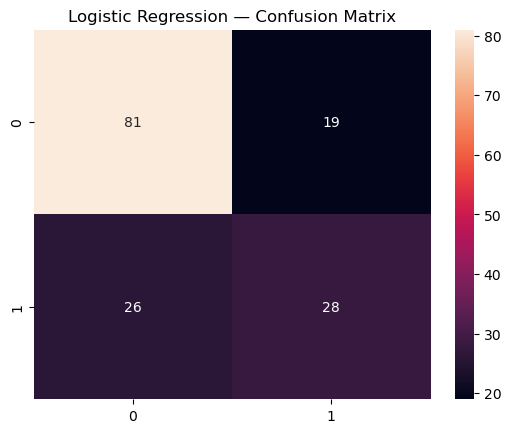

Model saved at: C:\Users\Rajesh Kinjarapu\Desktop\Smart Health Assistant\models\logistic_model.pkl
Logistic Regression Model Saved!


In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)

# Predictions
log_pred = log_model.predict(X_test)

# Evaluation
print("📌 Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("\nClassification Report:\n", classification_report(y_test, log_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, log_pred), annot=True, fmt='d')
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

# Save Pickle
model_path = r"C:\Users\Rajesh Kinjarapu\Desktop\Smart Health Assistant\models\logistic_model.pkl"
pickle.dump(log_model, open(model_path, "wb"))
print("Model saved at:", model_path)

print("Logistic Regression Model Saved!")


## SVM

📌 SVM Accuracy: 0.7402597402597403

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.86      0.81       100
           1       0.67      0.52      0.58        54

    accuracy                           0.74       154
   macro avg       0.72      0.69      0.70       154
weighted avg       0.73      0.74      0.73       154



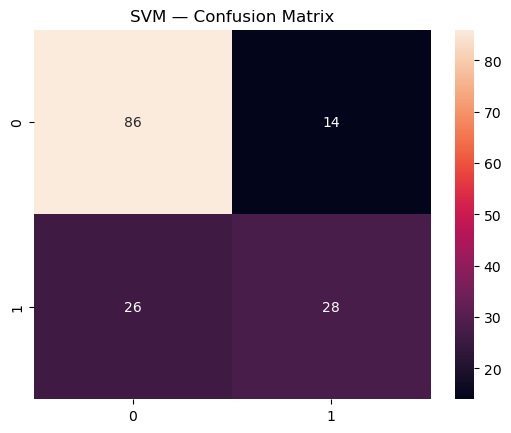

Model saved at: C:\Users\Rajesh Kinjarapu\Desktop\Smart Health Assistant\models\svm_model.pkl
SVM Model Saved!


In [76]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train, y_train)

# Predictions
svm_pred = svm_model.predict(X_test)

# Evaluation
print("📌 SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("\nClassification Report:\n", classification_report(y_test, svm_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d')
plt.title("SVM — Confusion Matrix")
plt.show()

# Save
model_path = r"C:\Users\Rajesh Kinjarapu\Desktop\Smart Health Assistant\models\svm_model.pkl"
pickle.dump(log_model, open(model_path, "wb"))
print("Model saved at:", model_path)
print("SVM Model Saved!")


## Random Forest

📌 Random Forest Accuracy: 0.7597402597402597

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



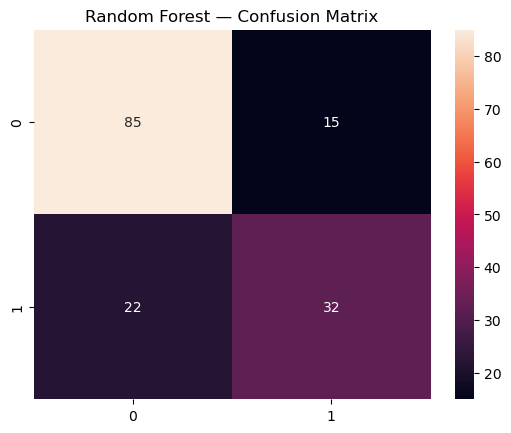

Model saved at: C:\Users\Rajesh Kinjarapu\Desktop\Smart Health Assistant\models\diabetes_rf_model.pkl
Random Forest Model Saved!


In [79]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
print("📌 Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d')
plt.title("Random Forest — Confusion Matrix")
plt.show()

# Save
model_path = r"C:\Users\Rajesh Kinjarapu\Desktop\Smart Health Assistant\models\diabetes_rf_model.pkl"
pickle.dump(log_model, open(model_path, "wb"))
print("Model saved at:", model_path)
print("Random Forest Model Saved!")


## XGBoost

📌 XGBoost Accuracy: 0.7727272727272727

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.85      0.83       100
           1       0.69      0.63      0.66        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



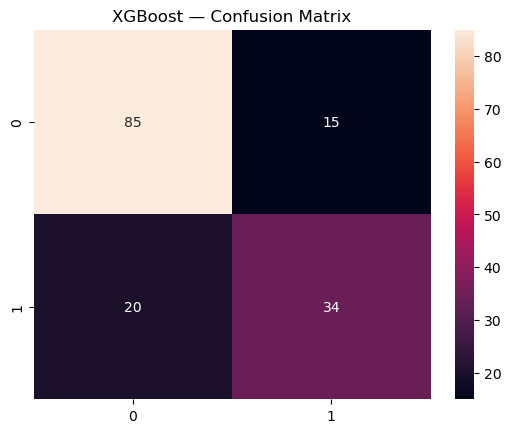

Model saved at: C:\Users\Rajesh Kinjarapu\Desktop\Smart Health Assistant\models\diabetes_xgb_model.pkl
XGBoost Model Saved!


In [82]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test)

# Evaluation
print("📌 XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print("\nClassification Report:\n", classification_report(y_test, xgb_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d')
plt.title("XGBoost — Confusion Matrix")
plt.show()

# Save
model_path = r"C:\Users\Rajesh Kinjarapu\Desktop\Smart Health Assistant\models\diabetes_xgb_model.pkl"
pickle.dump(log_model, open(model_path, "wb"))
print("Model saved at:", model_path)
print("XGBoost Model Saved!")


In [84]:
# Cross Validation 

from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": log_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name}: Mean CV = {scores.mean():.4f}, Std = {scores.std():.4f}")


Logistic Regression: Mean CV = 0.7643, Std = 0.0206
SVM: Mean CV = 0.7592, Std = 0.0332
Random Forest: Mean CV = 0.7448, Std = 0.0312
XGBoost: Mean CV = 0.7409, Std = 0.0278


In [86]:
accuracies = {
    "Logistic Regression": accuracy_score(y_test, log_pred),
    "SVM": accuracy_score(y_test, svm_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
    "XGBoost": accuracy_score(y_test, xgb_pred)
}

best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]

print("🏆 Best Model =", best_model_name)


🏆 Best Model = XGBoost


In [92]:
pickle.dump(
    xgb_model,
    open(r"C:\Users\Rajesh Kinjarapu\Desktop\Smart Health Assistant\models\diabetes_model.pkl", "wb")
)

pickle.dump(
    scaler,
    open(r"C:\Users\Rajesh Kinjarapu\Desktop\Smart Health Assistant\models\diabetes_scaler.pkl", "wb")
)

print("🔥 Final XGBoost Diabetes Model + Scaler Saved Successfully!")


🔥 Final XGBoost Diabetes Model + Scaler Saved Successfully!


In [7]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Rajesh Kinjarapu\Desktop\Smart Health Assistant\Datasets\diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
# Example, you may have different ones
df["Glucose_BMI"] = df["Glucose"] / df["BMI"]
df["Insulin_Glucose"] = df["Insulin"] / df["Glucose"]


In [11]:
X = df.drop("Outcome", axis=1)


In [13]:
list(X.columns)


['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Glucose_BMI',
 'Insulin_Glucose']